# Artifact-Based Plotting Demo

The following cells demonstrate the new artifact-based plotting workflow:
1. **Generate data** using scripts (one-time)
2. **Plot from saved artifacts** (fast, reproducible)

In [34]:
# Setup: imports and autoreload for development
%load_ext autoreload
%autoreload 2

import plots
from spins_sdp.scripts import exact_ground_energy, npa_energy_lb
from spins_sdp.utils import iter_result_runs, format_result_runs_table

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1: Generate Artifacts (Run Once)

These scripts compute exact ground energies and SDP lower bounds, saving results to disk.
Re-running with `--resume` only computes missing N values.

In [35]:
# Generate exact ground energies for the Ising model
exact_ground_energy.main([
    "--model", "ising",
    "--N-min", "2",
    "--N-max", "12",
    "--J", "1", "--h", "0.7", "--k", "0.3",
    "--boundary", "periodic",
    "--resume",
])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\f0e28cf3d0e38590


0

In [36]:
# Generate SDP lower bounds using NPA level 1
npa_energy_lb.main([
    "--model", "ising",
    "--basis", "npa",
    "--npa-level", "1",
    "--N-min", "2",
    "--N-max", "12",
    "--J", "1", "--h", "0.7", "--k", "0.3",
    "--boundary", "periodic",
    "--solver", "MOSEK",
    "--resume",
])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\07334ffd01abbf11


0

## Step 2: List Available Runs

Use the `list_runs` utilities to see what artifacts are stored.

In [56]:
# View stored exact ground energy runs
from spins_sdp.utils import list_exact_runs
list_exact_runs()

artifact               v   hash             max_N updated_at           model          boundary  basis              npa_k 
-------------------------------------------------------------------------------------------------------------------------
spin_exact_ground_eneâ€¦ v1  04c74a7ae54a1815 4     2026-01-22T16:17:29Z heisenberg_j2  periodic                           
spin_exact_ground_eneâ€¦ v1  2b91e99e24e6095a 4     2026-01-22T16:17:29Z heisenberg_j2  periodic                           
spin_exact_ground_eneâ€¦ v1  8b64f864e20d738e 4     2026-01-22T16:17:29Z heisenberg_j2  periodic                           
spin_exact_ground_eneâ€¦ v1  af44b6816fc66636 4     2026-01-22T16:17:29Z heisenberg_j2  periodic                           
spin_exact_ground_eneâ€¦ v1  b452107f935791bc 4     2026-01-22T16:17:29Z heisenberg_j2  periodic                           
spin_exact_ground_eneâ€¦ v1  b600d698458f7bca 4     2026-01-22T16:17:29Z heisenberg_j2  periodic                           
spin_exact_g

In [57]:
# View stored NPA lower bound runs
from spins_sdp.utils import list_lb_runs
list_lb_runs()

artifact               v   hash             max_N updated_at           model          boundary  basis              npa_k 
-------------------------------------------------------------------------------------------------------------------------
spin_moment_energy_lb  v1  71f3e03227592f66 4     2026-01-22T16:18:05Z heisenberg_j2  periodic  heisenberg_j2_strâ€¦       
spin_moment_energy_lb  v1  e2e4158a6576ad8b 4     2026-01-22T16:18:04Z heisenberg_j2  periodic  heisenberg_j2_strâ€¦       
spin_moment_energy_lb  v1  2476d7561f5c559a 4     2026-01-22T16:18:03Z heisenberg_j2  periodic  heisenberg_j2_weak       
spin_moment_energy_lb  v1  5b5a8d554997eeed 4     2026-01-22T16:18:00Z heisenberg_j2  periodic  heisenberg_j2_weak       
spin_moment_energy_lb  v1  274fe120f45c7051 4     2026-01-22T16:17:56Z heisenberg_j2  periodic  heisenberg_j2_weak       
spin_moment_energy_lb  v1  eb81c2d0fb7595db 4     2026-01-22T16:17:53Z heisenberg_j2  periodic  heisenberg_j2_weak       
spin_moment_energy_l

## Step 3: Plot from Artifacts

The artifact-based plotting functions load data from saved runs.

### Comparing Exact vs SDP Lower Bound

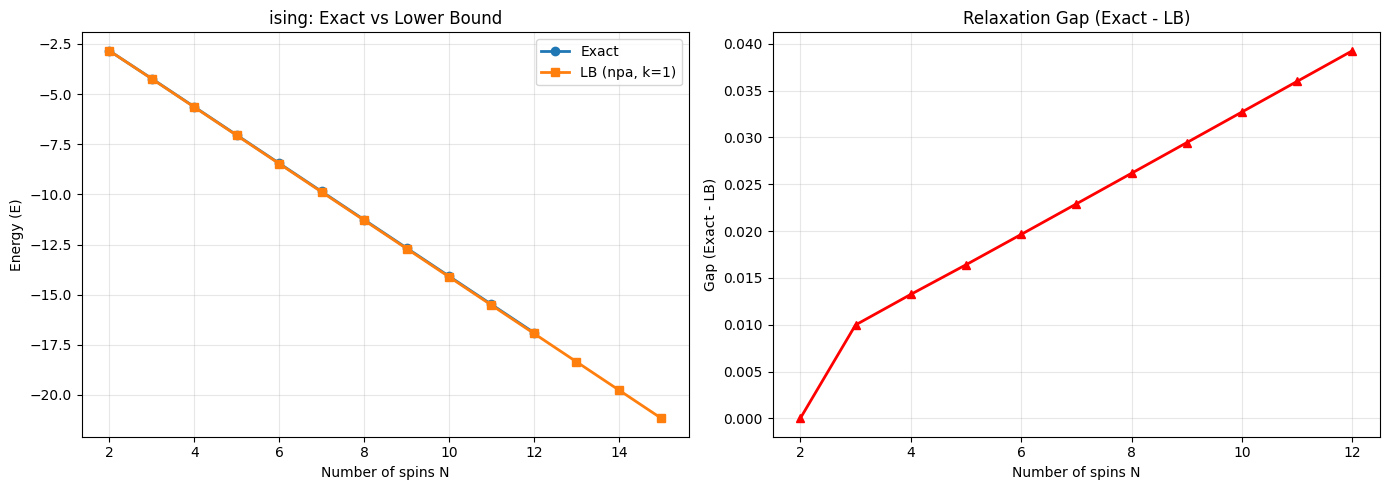

In [41]:
# Plot exact vs NPA lower bound for the Ising model
# Uses parameter-based lookup to find matching artifacts
from plots import plot_exact_vs_lb

_ = plot_exact_vs_lb(
    model="ising",
    model_params={"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    npa_level=1,
    lb_basis="npa",
)

### Utility Plots (Computed On-the-Fly)

Some plotting utilities perform quick computations directly without needing stored artifacts.

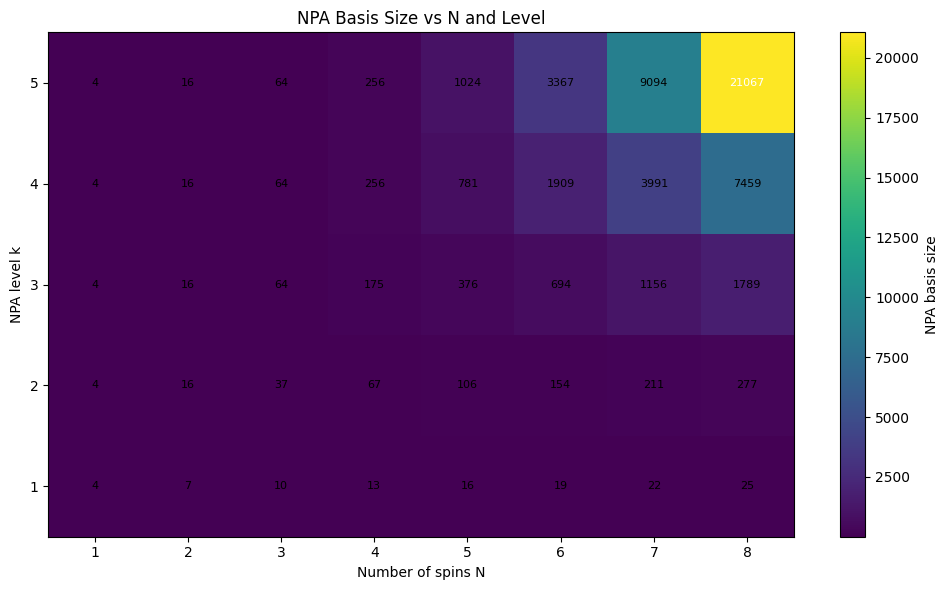

In [55]:
# NPA basis size heatmap: visualize how basis size scales with N and NPA level
from plots import npa_basis_size_heatmap

_ = npa_basis_size_heatmap(N_max=8, npa_level_max=5)

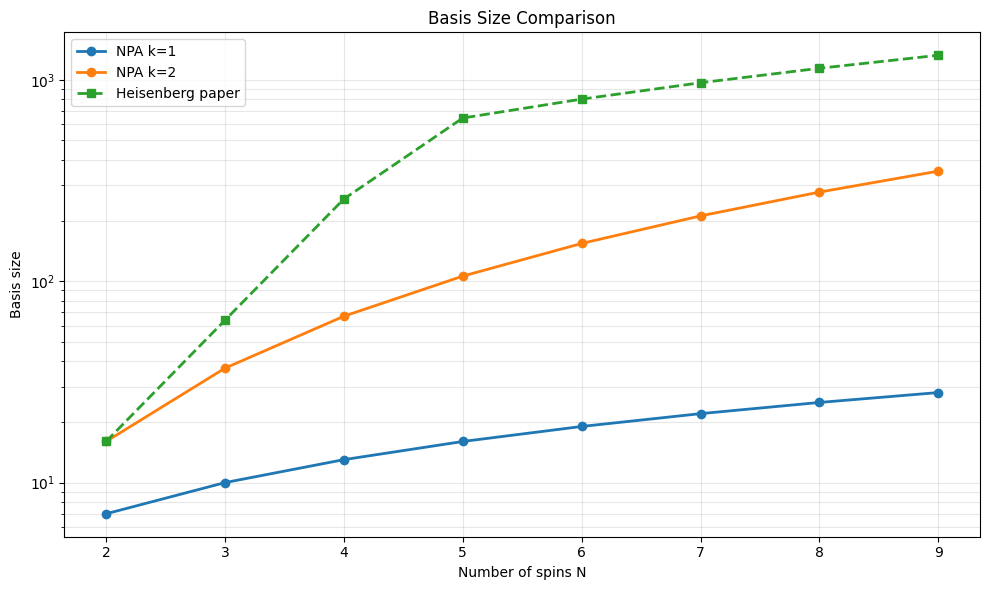

In [53]:
# Compare basis sizes across different methods
from plots import plot_basis_size_comparison

_ = plot_basis_size_comparison(
    N_values=range(2, 10),
    npa_levels=[1, 2],
    include_paper_basis=True,
)

## Runtime Comparison

Compare solve times between exact diagonalization and SDP relaxation.

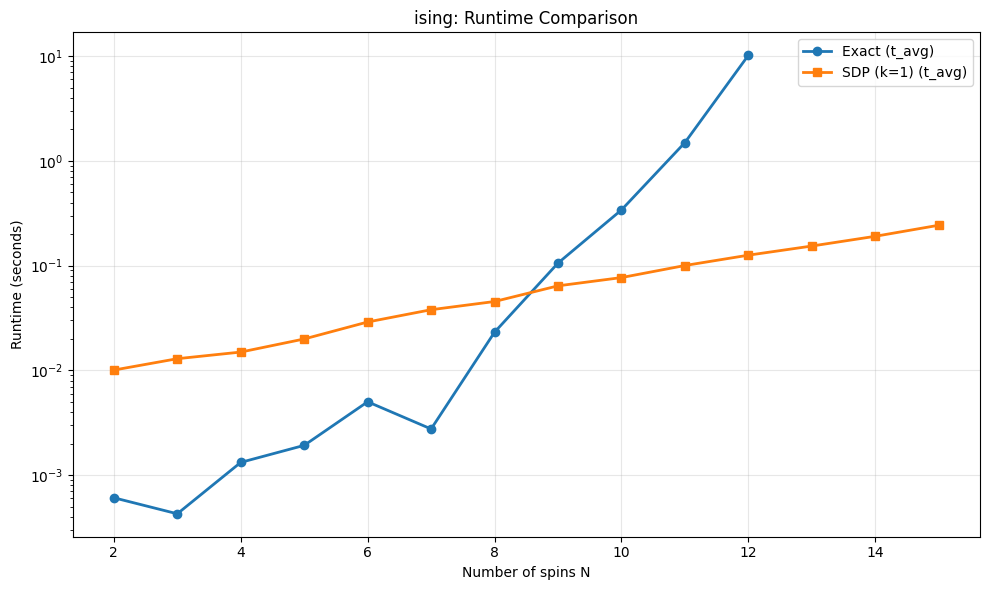

In [54]:
# Plot runtime comparison: Exact diagonalization vs SDP
from plots import plot_runtime_comparison

_ = plot_runtime_comparison(
    model="ising",
    model_params={"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    lb_basis="npa",
    npa_levels=[1],
    use="t_avg",
    logy=True,
)

## Heisenberg-J₂ Sweep Demo

The `plot_heisenberg_j2_sweep` function plots energy vs J₂ coupling for a fixed N.
First, we need to generate the artifacts for multiple J₂ values.

In [50]:
# Generate Heisenberg-J2 exact ground energies for several J2 values (N=4, small for demo)
J2_values = [0.0, 0.3, 0.5, 0.7, 1.0, 1.3, 1.5]

for J2 in J2_values:
    exact_ground_energy.main([
        "--model", "heisenberg_j2",
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--resume",
    ])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\2b91e99e24e6095a
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\af44b6816fc66636
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\04c74a7ae54a1815
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\d5681820b0b0e7ca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\8b64f864e20d738e
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b600d698458f7bca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b452107f935791bc


In [51]:
# Generate SDP lower bounds for the Heisenberg-J2 model
# Using heisenberg_j2_weak basis for J2 <= 1.0, heisenberg_j2_strong for J2 > 1.0

for J2 in J2_values:
    basis = "heisenberg_j2_weak" if J2 <= 1.0 else "heisenberg_j2_strong"
    npa_energy_lb.main([
        "--model", "heisenberg_j2",
        "--basis", basis,
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--solver", "MOSEK",
        "--resume",
    ])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\3c384c07a34e0516
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\eb81c2d0fb7595db
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\274fe120f45c7051
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\5b5a8d554997eeed
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\2476d7561f5c559a
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\e2e4158a6576ad8b
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\71f3e03227592f66


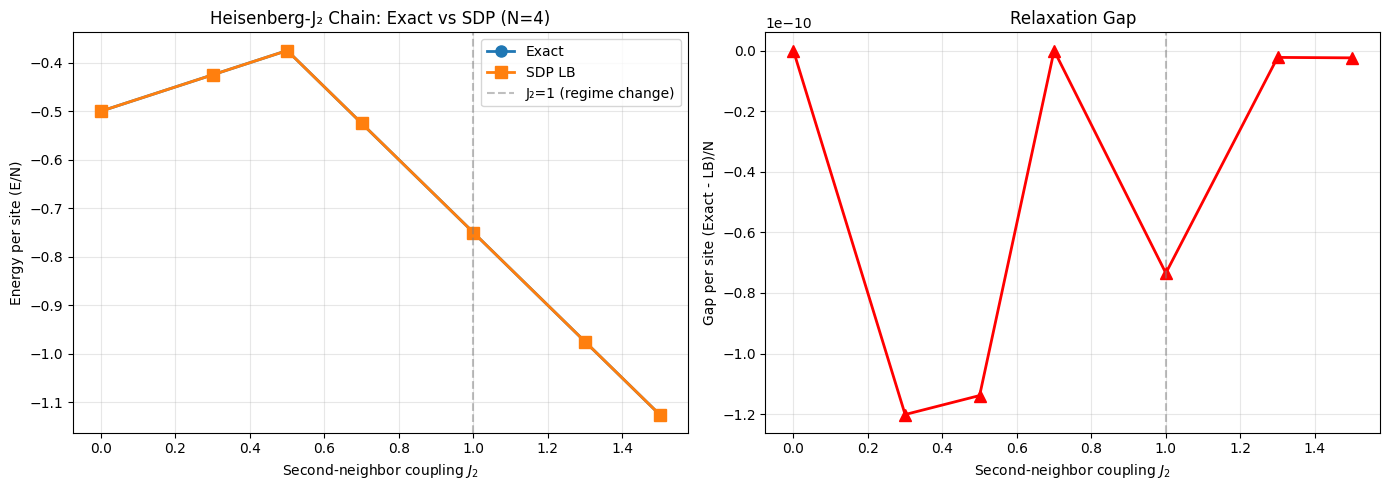

Heisenberg-J₂ Chain (N=4) - Exact vs SDP Comparison
J2         Exact E         SDP LB          Gap             Gap/N           Basis               
----------------------------------------------------------------------------------------------------
0.000      -2.00000000     -2.00000000     -8.65973959e-15 -2.16493490e-15 heisenberg_j2_weak  
0.300      -1.70000000     -1.70000000     -4.80385287e-10 -1.20096322e-10 heisenberg_j2_weak  
0.500      -1.50000000     -1.50000000     -4.55319338e-10 -1.13829834e-10 heisenberg_j2_weak  
0.700      -2.10000000     -2.10000000     -4.88498131e-15 -1.22124533e-15 heisenberg_j2_weak  
1.000      -3.00000000     -3.00000000     -2.93762792e-10 -7.34406980e-11 heisenberg_j2_weak  
1.300      -3.90000000     -3.90000000     -9.07540709e-12 -2.26885177e-12 heisenberg_j2_strong
1.500      -4.50000000     -4.50000000     -9.66604574e-12 -2.41651144e-12 heisenberg_j2_strong


In [52]:
# Plot Heisenberg-J2 sweep
from plots import plot_heisenberg_j2_sweep

_ = plot_heisenberg_j2_sweep(
    N=4,
    J2_values=J2_values,
    boundary="periodic",
    per_site=True,
)

## Summary

General workflow:

1. **Generate Artifacts** – Run scripts (`exact_ground_energy`, `npa_energy_lb`) to compute and save results with `--resume` for incremental updates.
2. **List Runs** – Use `list_exact_runs()` and `list_lb_runs()` to inspect stored data.
3. **Plot from Artifacts** – Call plotting functions to visualize results without recomputation:
   - `plot_exact_vs_lb()` – Compare exact vs SDP lower bound
   - `plot_runtime_comparison()` – Compare solve times
   - `plot_heisenberg_j2_sweep()` – Energy vs J₂ coupling
4. **Utility Plots** – Quick on-the-fly visualizations:
   - `npa_basis_size_heatmap()` – Heatmap of basis sizes
   - `plot_basis_size_comparison()` – Compare basis methods